In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
 
print("Libraries loaded!")
print(f"PyTorch version: {torch.__version__}")

Libraries loaded!
PyTorch version: 2.10.0+cu128


In [2]:
BASE_DIR = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'
df = pd.read_csv(f'{BASE_DIR}/HAM10000_metadata.csv')

img_dir_1 = f'{BASE_DIR}/HAM10000_images_part_1'
img_dir_2 = f'{BASE_DIR}/HAM10000_images_part_2'

def get_img_path(img_id):
    p1 = os.path.join(img_dir_1, img_id + '.jpg')
    p2 = os.path.join(img_dir_2, img_id + '.jpg')
    return p1 if os.path.exists(p1) else p2

df['path'] = df['image_id'].apply(get_img_path)
label_map = {'nv':0, 'mel':1, 'bkl':2, 'bcc':3, 'akiec':4, 'vasc':5, 'df':6}
label_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']
df['label'] = df['dx'].map(label_map)

print("Data loaded!")
print(df['dx'].value_counts())

Data loaded!
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [3]:
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, 'path']).convert('RGB')
        label = self.df.loc[idx, 'label']
        if self.transform:
            img = self.transform(img)
        return img, label
 
print("Dataset class defined!")

Dataset class defined!


In [4]:
# !! For InceptionV3: use 299x299
# !! For ResNet50 / EfficientNet: use 224x224
IMG_SIZE = 224  # <-- change to 224 for ResNet50 / EfficientNet
 
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)
 
print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
 
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
 
train_loader = DataLoader(SkinDataset(train_df, train_transform),
                          batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(SkinDataset(val_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(SkinDataset(test_df, val_transform),
                          batch_size=32, shuffle=False, num_workers=2)
 
print("DataLoaders ready!")
 

Train: 8012, Val: 1001, Test: 1002
DataLoaders ready!


In [5]:
# !! CHANGE THIS BLOCK FOR EACH MODEL !!
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
 
counts = df['label'].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
class_weights = torch.FloatTensor(weights).to(device)
 
# ── Option A: InceptionV3 (IMG_SIZE=299) ──────────────────────────────
# MODEL_NAME = 'InceptionV3'
# model = models.inception_v3(pretrained=True, aux_logits=True)
# model.fc = nn.Linear(model.fc.in_features, 7)
# model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, 7)
# model = model.to(device)
 
# ── Option B: ResNet50 (IMG_SIZE=224) — uncomment to use ──────────────
MODEL_NAME = 'ResNet50'
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 7)
model = model.to(device)
 
# ── Option C: EfficientNet-B0 (IMG_SIZE=224) — uncomment to use ───────
# from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
# MODEL_NAME = 'EfficientNet-B0'
# model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
# model.classifier[1] = nn.Linear(model.classifier[1].in_features, 7)
# model = model.to(device)
 
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
 
# Cosine annealing scheduler
NUM_EPOCHS = 15
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
 
print(f"Model: {MODEL_NAME}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model: ResNet50
Total parameters: 23,522,375


In [6]:
train_losses, val_losses, val_accs = [], [], []
best_val_loss = float('inf')
 
for epoch in range(NUM_EPOCHS):
    # ── Training ──
    model.train()
    running_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
 
        # InceptionV3 has aux output; others don't
        if MODEL_NAME == 'InceptionV3':
            outputs, aux = model(imgs)
            loss = criterion(outputs, labels) + 0.4 * criterion(aux, labels)
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
 
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
 
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()
 
    # ── Validation ──
    model.eval()
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
 
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100. * correct / total)
 
    # Save best model
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(model.state_dict(), f'{MODEL_NAME}_best.pth')
 
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_losses[-1]:.4f} | '
          f'Val Loss: {val_losses[-1]:.4f} | '
          f'Val Acc: {val_accs[-1]:.2f}% | '
          f'LR: {scheduler.get_last_lr()[0]:.6f}')
 
print(f'\nBest Val Loss: {best_val_loss:.4f}')

Epoch  1/15 | Train Loss: 1.2020 | Val Loss: 1.1000 | Val Acc: 50.75% | LR: 0.000099
Epoch  2/15 | Train Loss: 0.9372 | Val Loss: 0.8503 | Val Acc: 68.53% | LR: 0.000096
Epoch  3/15 | Train Loss: 0.7792 | Val Loss: 0.6893 | Val Acc: 71.83% | LR: 0.000091
Epoch  4/15 | Train Loss: 0.7228 | Val Loss: 0.6906 | Val Acc: 72.23% | LR: 0.000084
Epoch  5/15 | Train Loss: 0.6712 | Val Loss: 0.5624 | Val Acc: 72.23% | LR: 0.000075
Epoch  6/15 | Train Loss: 0.5700 | Val Loss: 0.5952 | Val Acc: 75.42% | LR: 0.000066
Epoch  7/15 | Train Loss: 0.4811 | Val Loss: 0.6665 | Val Acc: 73.73% | LR: 0.000056
Epoch  8/15 | Train Loss: 0.4200 | Val Loss: 0.6468 | Val Acc: 79.02% | LR: 0.000045
Epoch  9/15 | Train Loss: 0.3657 | Val Loss: 0.5848 | Val Acc: 77.32% | LR: 0.000035
Epoch 10/15 | Train Loss: 0.3123 | Val Loss: 0.6344 | Val Acc: 82.22% | LR: 0.000026
Epoch 11/15 | Train Loss: 0.2792 | Val Loss: 0.5794 | Val Acc: 84.52% | LR: 0.000017
Epoch 12/15 | Train Loss: 0.2210 | Val Loss: 0.6411 | Val Acc: 85

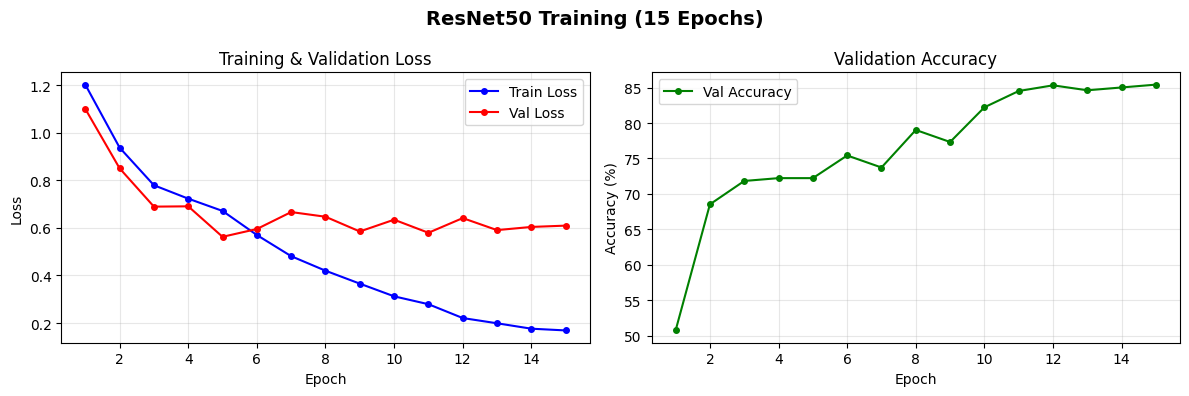

Saved: ResNet50_15epoch_curves.png


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'{MODEL_NAME} Training (15 Epochs)',
             fontsize=14, fontweight='bold')
 
epochs_range = range(1, NUM_EPOCHS + 1)
 
ax1.plot(epochs_range, train_losses, 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, val_losses,   'r-o', markersize=4, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)
 
ax2.plot(epochs_range, val_accs, 'g-o', markersize=4, label='Val Accuracy')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_15epoch_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {MODEL_NAME}_15epoch_curves.png")

In [10]:
# Cell 8 开头改成：
MODEL_NAME = 'ResNet50'
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 7)
model = model.to(device)
model.load_state_dict(torch.load('ResNet50_best.pth'))
model.eval()
print("ResNet50 best model loaded!")

# 然后接着跑之前Cell 8和Cell 9的完整代码

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet50 best model loaded!


In [11]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

label_names = ['nv', 'mel', 'bkl', 'bcc', 'akiec', 'vasc', 'df']

model.eval()
all_probs  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs  = np.concatenate(all_probs,  axis=0)
all_labels = np.concatenate(all_labels, axis=0)

y_bin = label_binarize(all_labels, classes=list(range(7)))
auc_scores = {}
for i, name in enumerate(label_names):
    auc = roc_auc_score(y_bin[:, i], all_probs[:, i])
    auc_scores[name] = auc
    print(f'  {name:6s}: AUC = {auc:.4f}')

macro_auc = np.mean(list(auc_scores.values()))
print(f'\nMacro-avg AUC: {macro_auc:.4f}')

  nv    : AUC = 0.9484
  mel   : AUC = 0.8686
  bkl   : AUC = 0.9335
  bcc   : AUC = 0.9674
  akiec : AUC = 0.9736
  vasc  : AUC = 0.9988
  df    : AUC = 0.9979

Macro-avg AUC: 0.9555


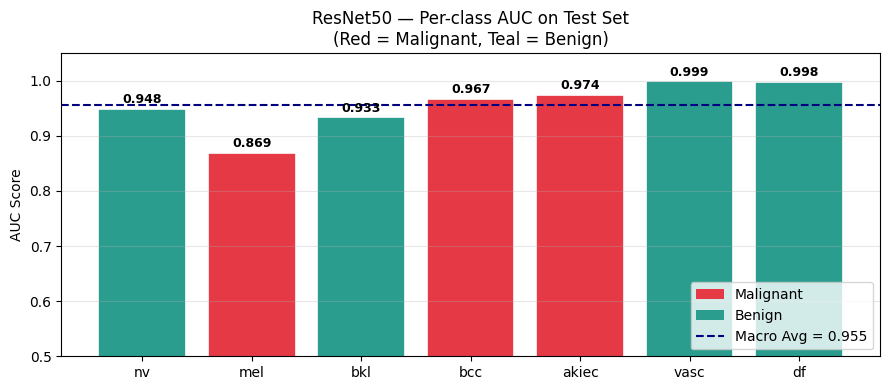

Saved: ResNet50_per_class_auc.png


In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#E63946' if n in ['mel','bcc','akiec'] else '#2A9D8F'
          for n in label_names]

bars = ax.bar(label_names, [auc_scores[n] for n in label_names],
              color=colors, edgecolor='white', linewidth=1.2)

for bar, name in zip(bars, label_names):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{auc_scores[name]:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(macro_auc, color='navy', linestyle='--', linewidth=1.5)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('AUC Score')
ax.set_title(f'{MODEL_NAME} — Per-class AUC on Test Set\n'
             f'(Red = Malignant, Teal = Benign)')

legend_elements = [Patch(facecolor='#E63946', label='Malignant'),
                   Patch(facecolor='#2A9D8F', label='Benign'),
                   plt.Line2D([0],[0], color='navy', linestyle='--',
                              label=f'Macro Avg = {macro_auc:.3f}')]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_per_class_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {MODEL_NAME}_per_class_auc.png")

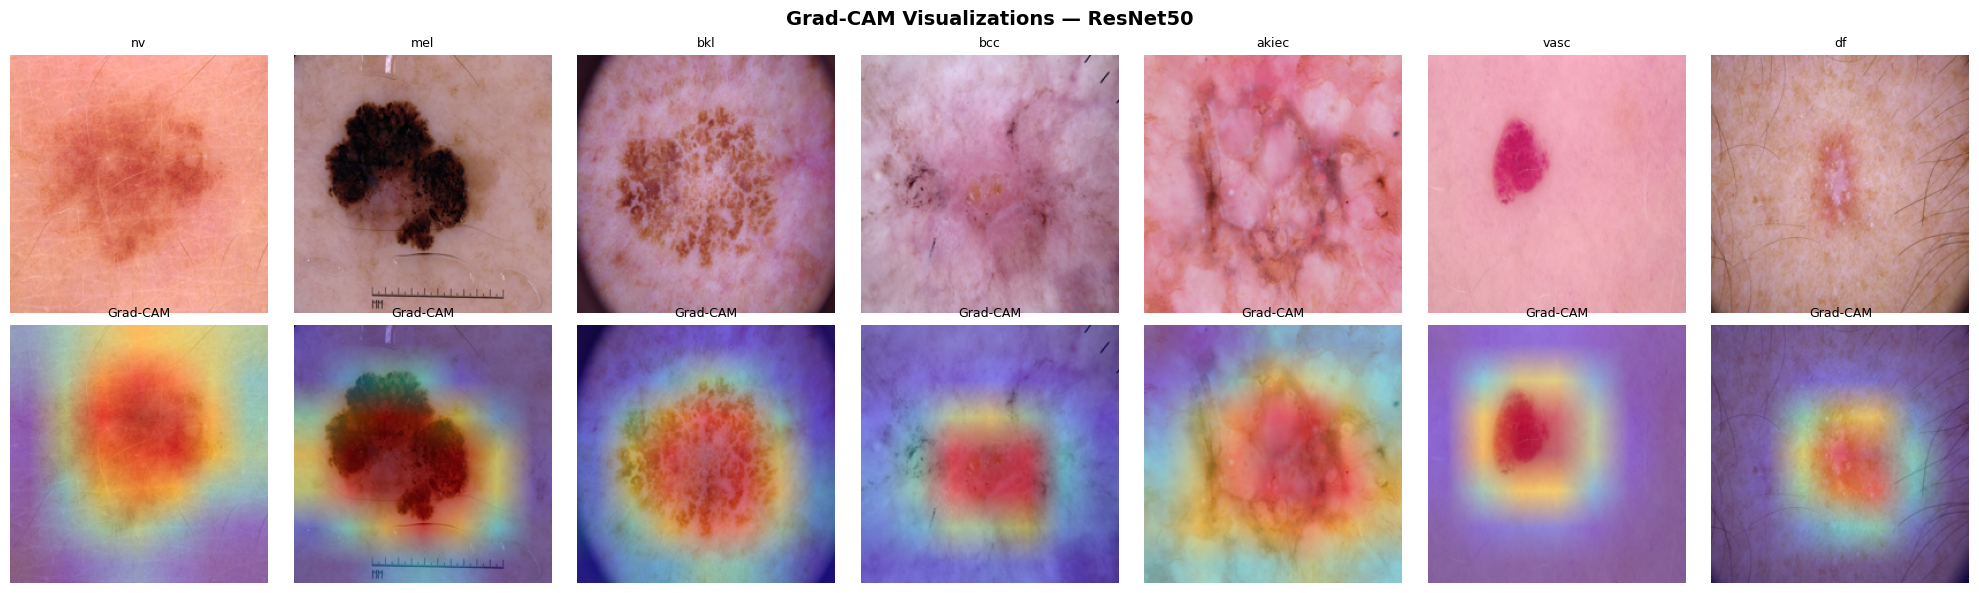

Saved: resnet50_gradcam.png


In [13]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 加载ResNet50最佳模型
model.load_state_dict(torch.load('ResNet50_best.pth'))
model.eval()

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)
    
    def _save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# ResNet50的target layer是最后一个残差块
gradcam = GradCAM(model, model.layer4[-1])

label_names = ['nv','mel','bkl','bcc','akiec','vasc','df']
val_transform_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle('Grad-CAM Visualizations — ResNet50', fontsize=14, fontweight='bold')

for i, label_idx in enumerate(range(7)):
    sample = test_df[test_df['label'] == label_idx].iloc[0]
    img_orig = Image.open(sample['path']).convert('RGB')
    img_resized = img_orig.resize((224, 224))
    
    inp = val_transform_resnet(img_orig).unsqueeze(0).to(device)
    cam = gradcam.generate(inp, label_idx)
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = cv2.resize(heatmap, (224, 224))
    overlay = np.array(img_resized) * 0.6 + heatmap * 0.4
    overlay = np.uint8(overlay)
    
    axes[0][i].imshow(img_resized)
    axes[0][i].set_title(label_names[label_idx], fontsize=9)
    axes[0][i].axis('off')
    axes[1][i].imshow(overlay)
    axes[1][i].set_title('Grad-CAM', fontsize=9)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('resnet50_gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: resnet50_gradcam.png")